In [13]:
%matplotlib inline

In [1]:
%cd ~/state

# Colab-specific config for pytorch lightning
import os 
# os.environ['MPLBACKEND'] = 'Agg'
from huggingface_hub import snapshot_download
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

/home/averywpx/state


In [2]:
raw_sub_hepg2_path = "/data/storage/Replogle/raw_data/GSE264667_hepg2_raw_singlecell_01_sub.h5ad"
processed_sub_hepg2_path = "/data/storage/Replogle/processed_data/replogle_hepg2_sub.h5ad"
preprocessed_ko_lst_path = "/data/storage/X-Atlas/HCT116/h5ad/intermediate_data/processed_hepg2_ko_cells.txt"
preprocessed_np_lst_path = "/data/storage/X-Atlas/HCT116/h5ad/intermediate_data/processed_hepg2_np_cells.txt"

In [3]:
def read_lst(path):
    with open(path, "r") as file:
        lst = file.read().splitlines()
    return lst


In [4]:
ko_lst = read_lst(preprocessed_ko_lst_path)
np_lst = read_lst(preprocessed_np_lst_path)

In [17]:
1285+597+500

2382

In [18]:
75+48+46+47+45+1024

1285

In [21]:
59+40+2+7+66+86+4+145+46+142

597

In [5]:
raw_sub_hepg2_adata = sc.read_h5ad(raw_sub_hepg2_path)
preprocessed_sub_ds_ntc_adata = sc.read_h5ad(processed_sub_hepg2_path)

In [20]:
preprocessed_sub_ds_ntc_adata.obs["gene"].value_counts()

gene
TFAM             1166
non-targeting     500
RHOQ              145
CDK1              134
MYBL2             133
CDC42             117
MTOR               66
PTEN               63
MAP2K7             53
LRP5               50
MYC                49
S100A1             46
FOXO1              43
HAMP               40
PRKCA              37
Name: count, dtype: int64

In [12]:
# add flags
preprocessed_sub_ds_ntc_adata.obs["mixscape_class"] = np.where(
    preprocessed_sub_ds_ntc_adata.obs["gene"] == "non-targeting",
    "NTC",
    "None"
)
preprocessed_sub_ds_ntc_adata.obs["mixscape_class"] = np.where(
    preprocessed_sub_ds_ntc_adata.obs_names.isin(ko_lst),
    "KO",
    preprocessed_sub_ds_ntc_adata.obs["mixscape_class"]
)
preprocessed_sub_ds_ntc_adata.obs["mixscape_class"] = np.where(
    preprocessed_sub_ds_ntc_adata.obs_names.isin(np_lst),
    "NP",
    preprocessed_sub_ds_ntc_adata.obs["mixscape_class"]
)
preprocessed_sub_ds_ntc_adata.obs["mixscape_class"].value_counts()

mixscape_class
KO      1285
NP       597
NTC      500
None     260
Name: count, dtype: int64

In [27]:
preprocessed_sub_ds_ntc_adata.obs_names.isin(ko_lst)

array([ True,  True, False, ..., False, False, False], shape=(2642,))

In [4]:
# Scale
sc.pp.scale(preprocessed_sub_ds_ntc_adata, max_value=10)

# PCA
sc.tl.pca(preprocessed_sub_ds_ntc_adata)

# Nearest neighbors
sc.pp.neighbors(
    preprocessed_sub_ds_ntc_adata,
    n_neighbors=15,
    n_pcs=50
)

# UMAP
sc.tl.umap(preprocessed_sub_ds_ntc_adata)

# t-SNE
sc.tl.tsne(preprocessed_sub_ds_ntc_adata)

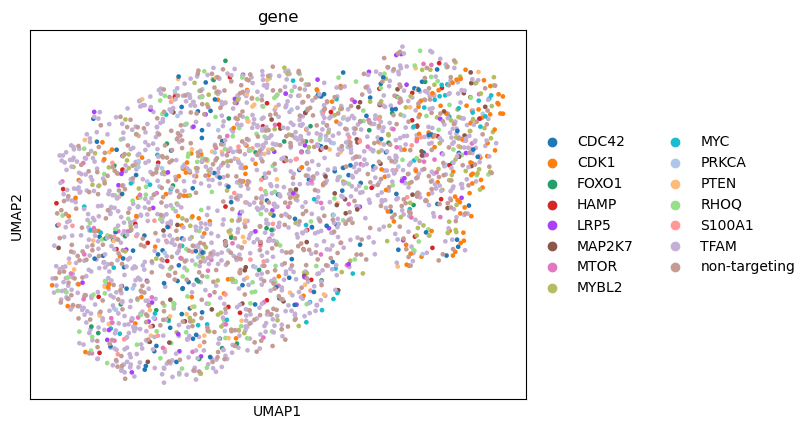

In [5]:
sc.pl.umap(
    preprocessed_sub_ds_ntc_adata,
    color=["gene"]
)


# sc.pl.umap(
#     preprocessed_sub_ds_ntc_adata,
#     color=["gene"]
# )

# sc.pl.umap(
#     preprocessed_sub_ds_ntc_adata,
#     color=["mixscape_class"]
# )



In [8]:
plt.savefig("/home/averywpx/Documents/scripts/umap_gene.png", dpi=300, bbox_inches="tight")

In [11]:
import matplotlib
print(matplotlib.get_backend())

Agg


In [12]:
preprocessed_sub_ds_ntc_adata.obsm.keys()

KeysView(AxisArrays with keys: X_hvg, X_pca, X_umap, X_tsne)

In [4]:
# Normalize
sc.pp.normalize_total(preprocessed_sub_ds_ntc_adata)
sc.pp.log1p(preprocessed_sub_ds_ntc_adata)

# Highly variable genes
sc.pp.highly_variable_genes(
    preprocessed_sub_ds_ntc_adata,
    n_top_genes=3000
)

preprocessed_sub_ds_ntc_adata = preprocessed_sub_ds_ntc_adata[:, preprocessed_sub_ds_ntc_adata.var.highly_variable]

# Scale
sc.pp.scale(preprocessed_sub_ds_ntc_adata, max_value=10)

# PCA
sc.tl.pca(preprocessed_sub_ds_ntc_adata)

# Nearest neighbors
sc.pp.neighbors(
    preprocessed_sub_ds_ntc_adata,
    n_neighbors=15,
    n_pcs=50
)

# UMAP
sc.tl.umap(preprocessed_sub_ds_ntc_adata)

# t-SNE
sc.tl.tsne(preprocessed_sub_ds_ntc_adata)


/home/averywpx/anaconda3/lib/python3.13/functools.py:934: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)


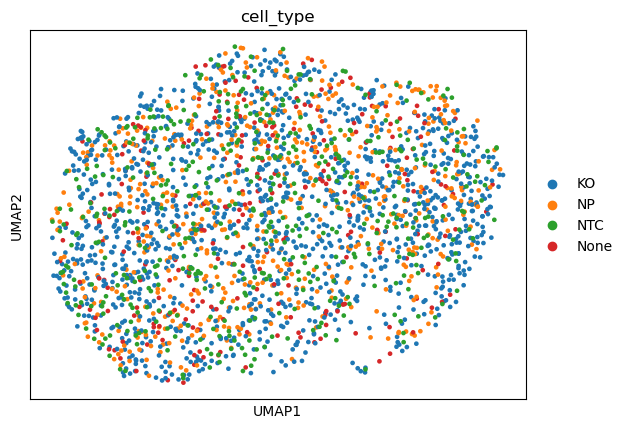

In [30]:
sc.pl.umap(
    preprocessed_sub_ds_ntc_adata,
    color=["mixscape_class"]
)

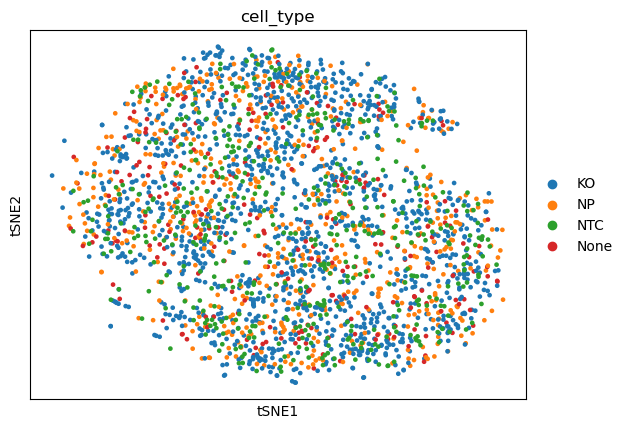

In [32]:
sc.pl.tsne(
    preprocessed_sub_ds_ntc_adata,
    color=["mixscape_class"]
)

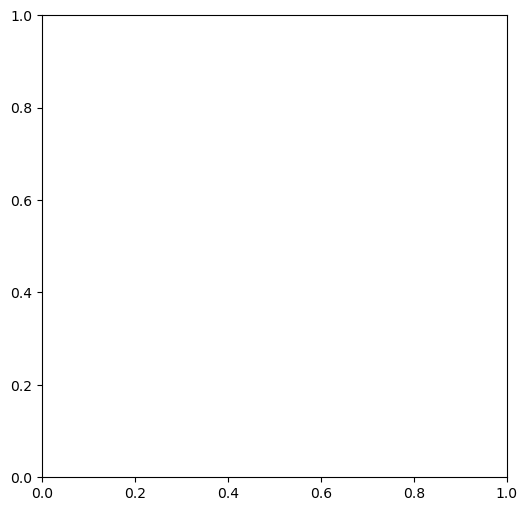

In [7]:
# PCA
sc.tl.pca(preprocessed_sub_ds_ntc_adata)

# Nearest neighbors
sc.pp.neighbors(
    preprocessed_sub_ds_ntc_adata,
    n_neighbors=15,
    n_pcs=50
)

# UMAP
sc.tl.umap(preprocessed_sub_ds_ntc_adata)

# t-SNE
sc.tl.tsne(preprocessed_sub_ds_ntc_adata)

<Axes: title={'center': 'mixscape_class'}, xlabel='UMAP1', ylabel='UMAP2'>

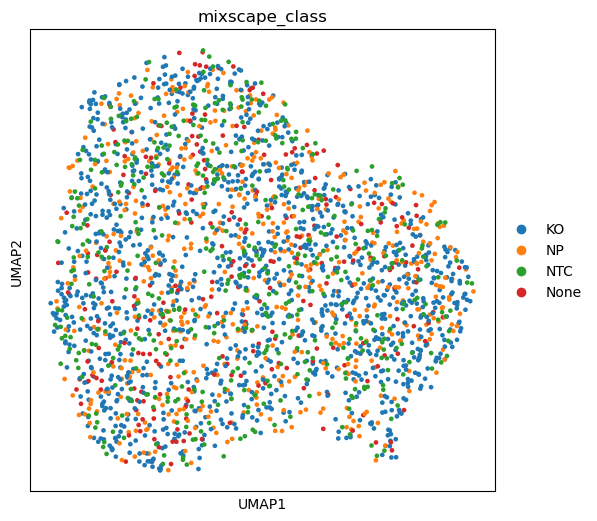

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

sc.pl.umap(
    preprocessed_sub_ds_ntc_adata,
    color=["mixscape_class"],
    ax=ax,
    show=False
)

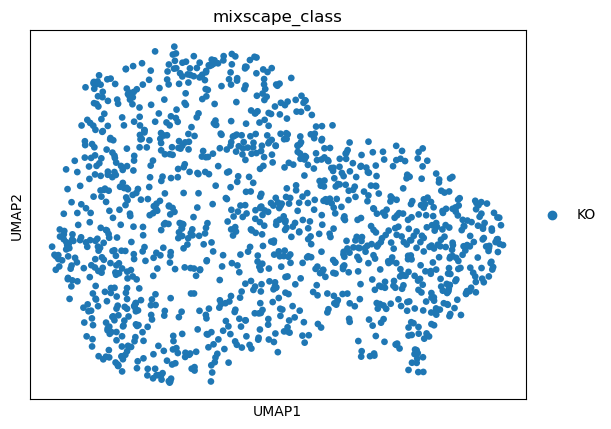

In [13]:
ko_adata = preprocessed_sub_ds_ntc_adata[
    preprocessed_sub_ds_ntc_adata.obs["mixscape_class"] == "KO"
].copy()

sc.pl.umap(ko_adata, color="mixscape_class")

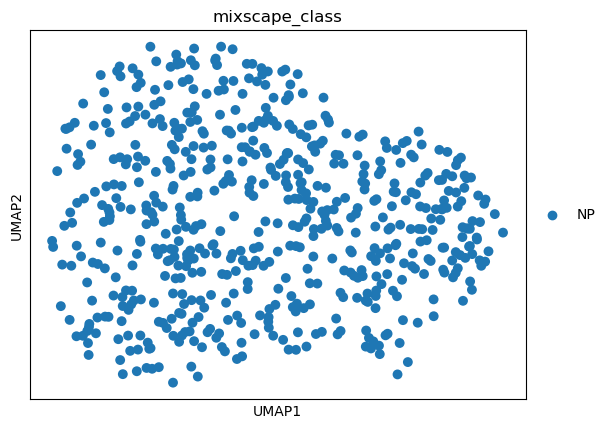

In [15]:
np_adata = preprocessed_sub_ds_ntc_adata[
    preprocessed_sub_ds_ntc_adata.obs["mixscape_class"] == "NP"
].copy()

sc.pl.umap(np_adata, color="mixscape_class")

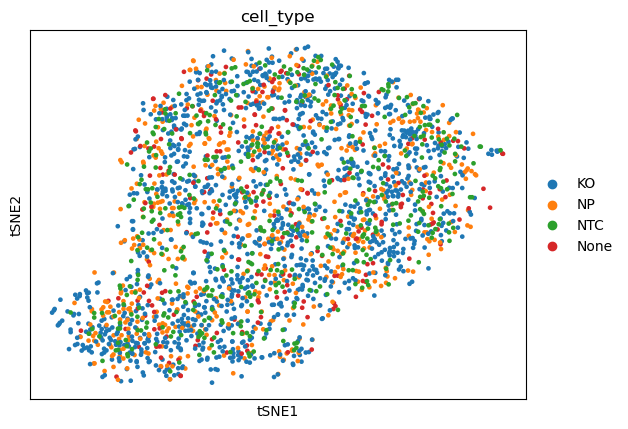

In [15]:
sc.pl.tsne(
    preprocessed_sub_ds_ntc_adata,
    color=["mixscape_class"]
)

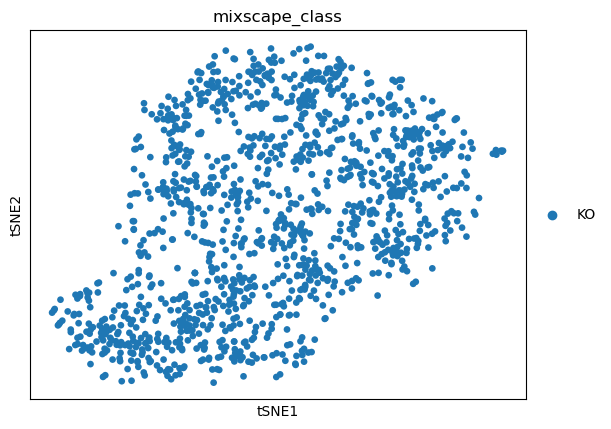

In [14]:
sc.pl.tsne(
    ko_adata,
    color=["mixscape_class"]
)

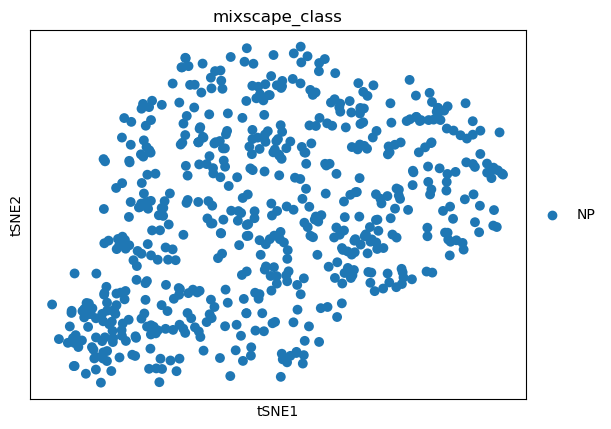

In [16]:
sc.pl.tsne(
    np_adata,
    color=["mixscape_class"]
)